In [37]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset

In [38]:

ROOT = Path("Dataset/bottle")

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

In [39]:

class BottleTrainDataset(Dataset):

    def __init__(self, root, transform=None):
        self.image_paths = list(
            (root / "train" / "good").glob("*.png")
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [40]:
train_dataset = BottleTrainDataset(
    ROOT,
    transform=transform
)

In [41]:
print("Number of training images:", len(train_dataset))
print("Image shape:", train_dataset[0].shape)
print ("Image tensor:", train_dataset[0])

Number of training images: 209
Image shape: torch.Size([1, 28, 28])
Image tensor: tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 0.9961, 0.9922, 0.9843, 0.9843, 0.9922,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          0.9961, 0.9529, 0.8039, 0.6745, 0.6157, 0.5686, 0.5725, 0.6196,
          0.7176, 0.8471, 0.9529, 0.9961, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9412,
          0.7294, 0.4706, 0.3059, 0.2588, 0.2549, 0.2549, 0.2667, 0.2667,
          0.2784, 0.3294, 0.4784, 0.7490, 0.9569, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9882, 0.8314, 0.4902,
          0.2980, 0.2667, 0.2627, 0.2588, 0.2667,

In [42]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [43]:
images = next(iter(train_loader))
print(images.shape)

torch.Size([64, 1, 28, 28])


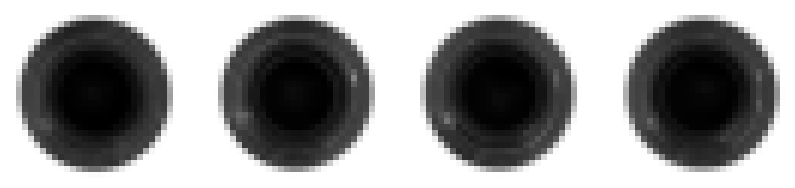

In [44]:
import matplotlib.pyplot as plt
images = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(4):

    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0),cmap = "gray")
    plt.axis("off")

plt.show()

In [45]:
class BottleTestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.image_paths = []
        self.labels = []
        test_path = root / "test"
        for defect_folder in test_path.iterdir():
            if not defect_folder.is_dir():
                continue

            if defect_folder.name == "good":
                label = 0
            else:
                label = 1
            for image_path in defect_folder.glob("*.png"):

                self.image_paths.append(image_path)
                self.labels.append(label)
                print(f"Image path: {image_path}, Label: {label}")
        self.transform = transform
        print(transform)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label

In [46]:
test_dataset = BottleTestDataset(
    ROOT,
    transform=transform
)

print("Number of test images:", len(test_dataset))

Image path: Dataset\bottle\test\broken_large\000.png, Label: 1
Image path: Dataset\bottle\test\broken_large\001.png, Label: 1
Image path: Dataset\bottle\test\broken_large\002.png, Label: 1
Image path: Dataset\bottle\test\broken_large\003.png, Label: 1
Image path: Dataset\bottle\test\broken_large\004.png, Label: 1
Image path: Dataset\bottle\test\broken_large\005.png, Label: 1
Image path: Dataset\bottle\test\broken_large\006.png, Label: 1
Image path: Dataset\bottle\test\broken_large\007.png, Label: 1
Image path: Dataset\bottle\test\broken_large\008.png, Label: 1
Image path: Dataset\bottle\test\broken_large\009.png, Label: 1
Image path: Dataset\bottle\test\broken_large\010.png, Label: 1
Image path: Dataset\bottle\test\broken_large\011.png, Label: 1
Image path: Dataset\bottle\test\broken_large\012.png, Label: 1
Image path: Dataset\bottle\test\broken_large\013.png, Label: 1
Image path: Dataset\bottle\test\broken_large\014.png, Label: 1
Image path: Dataset\bottle\test\broken_large\015.png, L

In [47]:
from collections import Counter
print(Counter(test_dataset.labels))

Counter({1: 63, 0: 20})


In [48]:
BATCH_SIZE = 64

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [49]:
print(train_dataset[0])
print(len(train_dataset))
print(train_dataset[0].shape)


tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 0.9961, 0.9922, 0.9843, 0.9843, 0.9922,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          0.9961, 0.9529, 0.8039, 0.6745, 0.6157, 0.5686, 0.5725, 0.6196,
          0.7176, 0.8471, 0.9529, 0.9961, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9412,
          0.7294, 0.4706, 0.3059, 0.2588, 0.2549, 0.2549, 0.2667, 0.2667,
          0.2784, 0.3294, 0.4784, 0.7490, 0.9569, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9882, 0.8314, 0.4902,
          0.2980, 0.2667, 0.2627, 0.2588, 0.2667, 0.2745, 0.2824, 0.2824,
          0.2824, 0.2902, 0.2941, 0.3176, 0.5647, 0.8941,

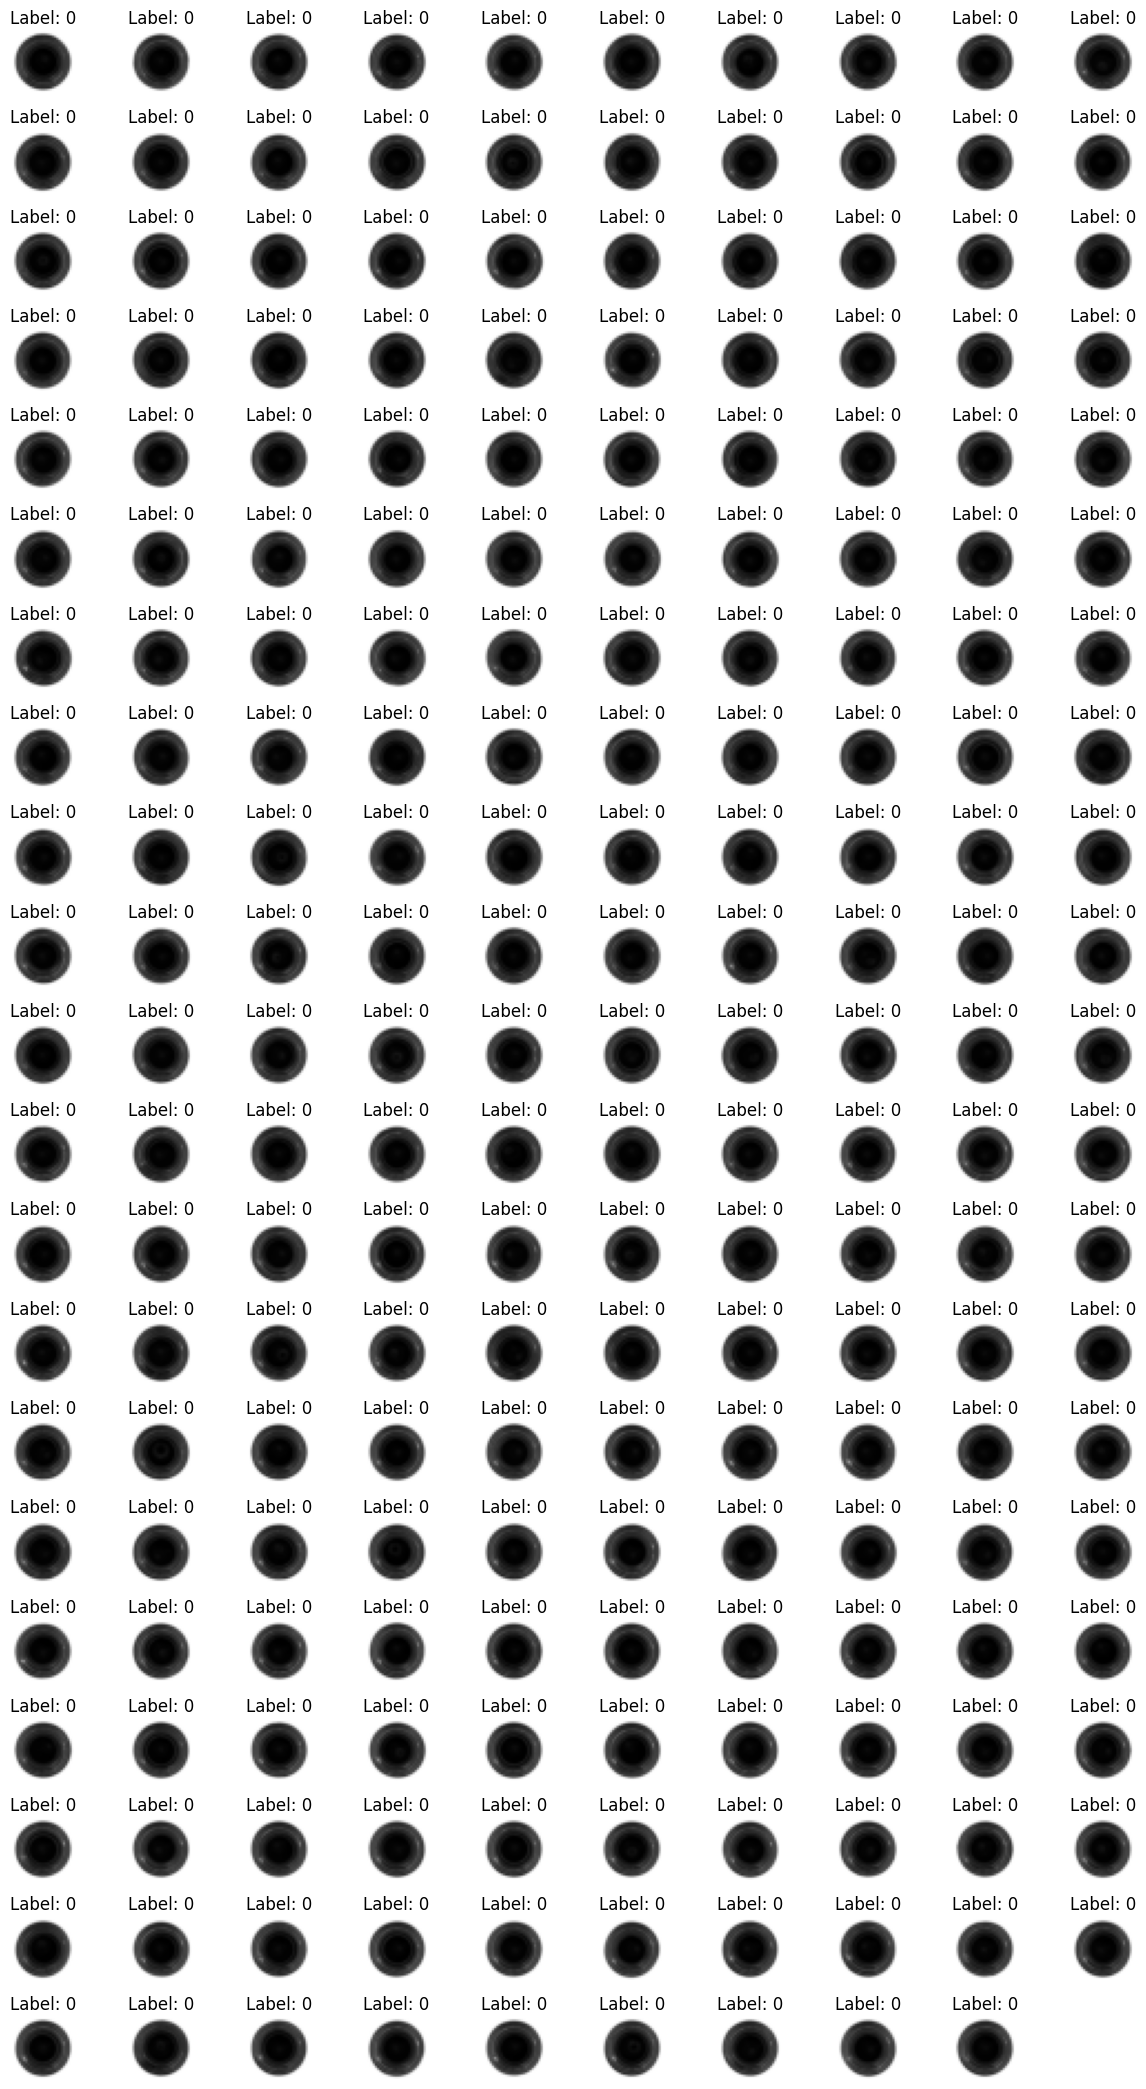

In [50]:
cols = 10
rows = (len(train_dataset) + cols - 1) // cols
plt.figure(figsize=(12,rows))
for i in range(len(train_dataset)):
    image = train_dataset[i]
    label  = 0 
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.permute(1, 2, 0),cmap = 'gray')
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

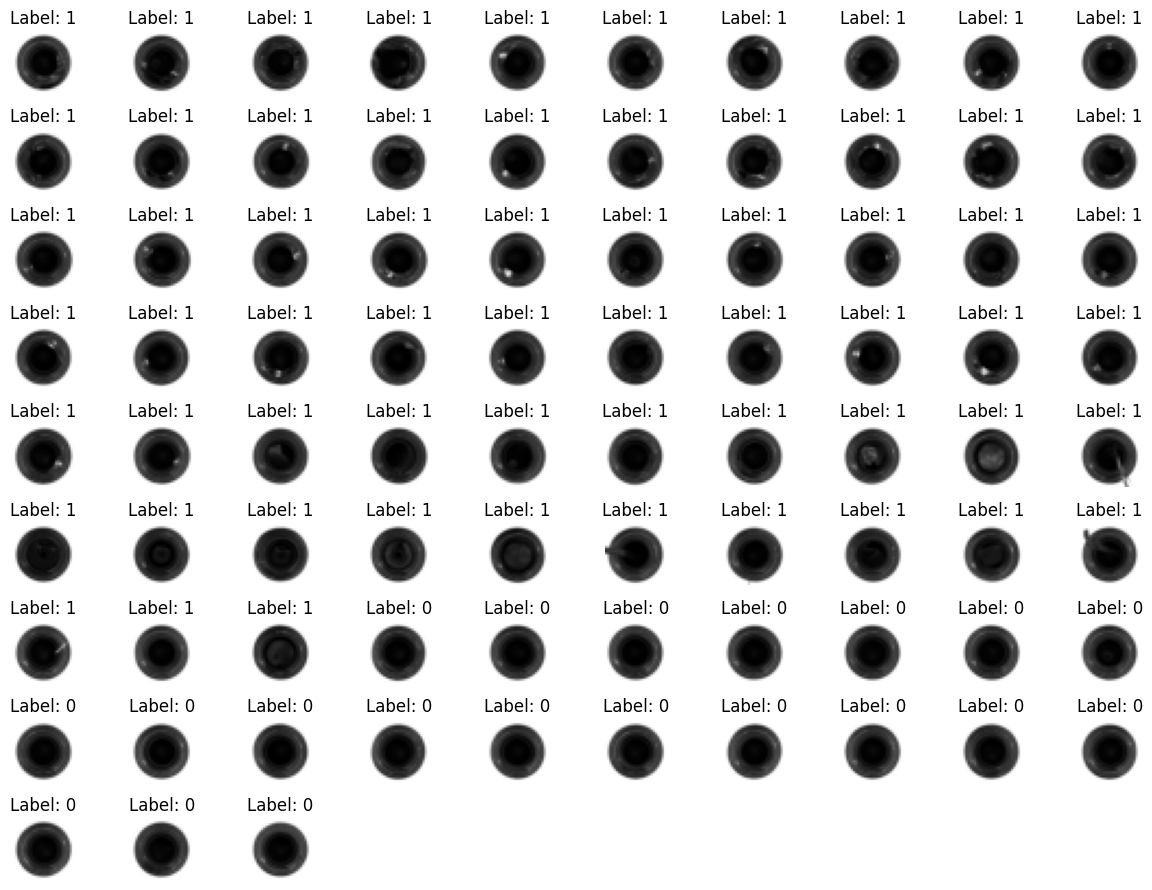

In [51]:
cols = 10
rows = (len(test_dataset) + cols - 1) // cols
plt.figure(figsize=(12,rows))
for i in range(len(test_dataset)):
    image = test_dataset[i][0]
    label = test_dataset[i][1]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.permute(1, 2, 0),cmap = "gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [52]:
from torch import nn, optim

In [53]:
class LLAutoencoder(nn.Module):
    def __init__(self):
        super (LLAutoencoder,self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
        )
    def forward(self,x):
        x = torch.flatten(x,start_dim =1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [54]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
x = torch.rand(3, 3).to(device)

Using device: cuda


In [55]:
torch.manual_seed(42)

In [56]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LLAutoencoder().to(device)

print(model)

LLAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [57]:
from torch.nn import MSELoss
loss_fn = MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [58]:
EPOCHS=10
train_losses = []
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images in train_loader:
        images = images.to(device)
        reconstructed = model(images)
        loss = loss_fn(reconstructed, images.view(images.size(0), -1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(
    f"Epoch [{epoch + 1}/{EPOCHS}], "
    f"Loss: {epoch_loss:.6f}"
)

Epoch [1/10], Loss: 0.121364
Epoch [2/10], Loss: 0.109725
Epoch [3/10], Loss: 0.075256
Epoch [4/10], Loss: 0.034119
Epoch [5/10], Loss: 0.023182
Epoch [6/10], Loss: 0.013373
Epoch [7/10], Loss: 0.006059
Epoch [8/10], Loss: 0.005968
Epoch [9/10], Loss: 0.004316
Epoch [10/10], Loss: 0.001975


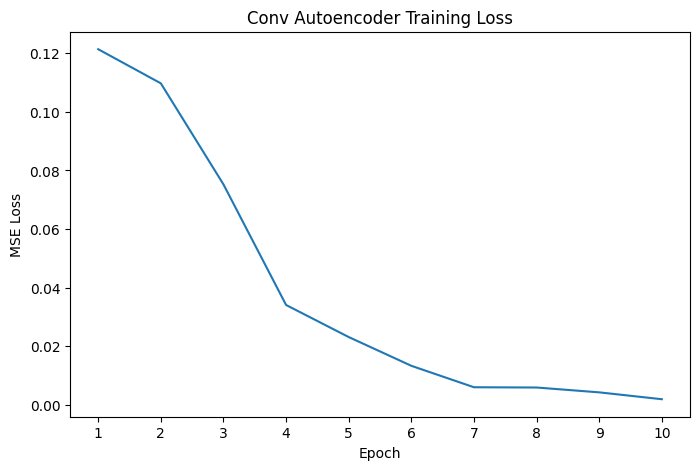

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, EPOCHS + 1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conv Autoencoder Training Loss")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

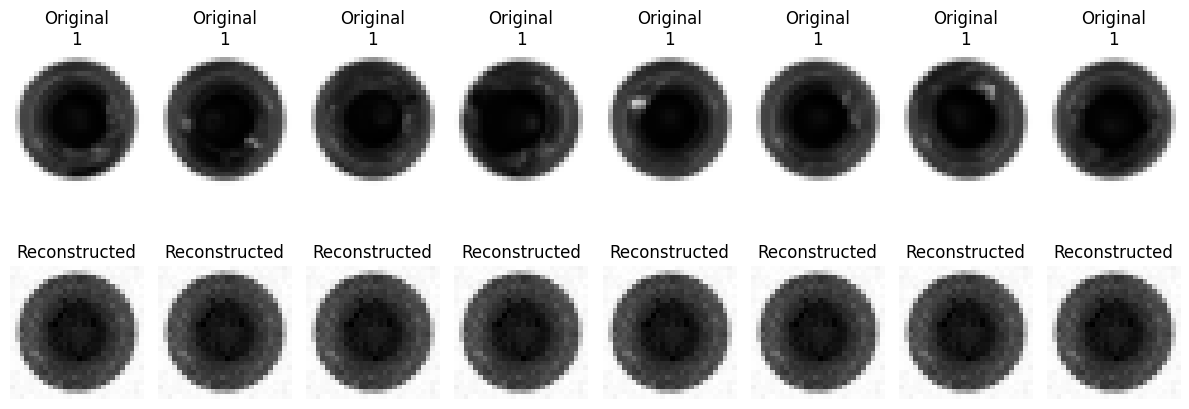

In [60]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

fig = plt.figure(figsize=(12, 5))

for i in range(8):

    plt.subplot(2, 8, i + 1)
    plt.imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )
    plt.title(f"Original\n{labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, 8, i + 9)
    plt.imshow(
        reconstructed[i].cpu().view(28, 28),
        cmap="gray"
    )
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [61]:
model.eval()

all_errors = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        original = images.view(images.size(0), -1)
        reconstructed = model(images)
        error = torch.mean(
            (original - reconstructed) ** 2,
            dim=1
        )

        all_errors.extend(error.cpu().numpy())
        all_labels.extend(labels.numpy())

In [62]:
threshold = 0.0020
predicted_labels = [
    1 if error > threshold else 0
    for error in all_errors
]

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(
    all_labels,
    predicted_labels
)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels , predicted_labels))

print("\nClassification Report:")
print(classification_report(all_labels, predicted_labels))

Accuracy: 0.7590361445783133

Confusion Matrix:
[[10 10]
 [10 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        20
           1       0.84      0.84      0.84        63

    accuracy                           0.76        83
   macro avg       0.67      0.67      0.67        83
weighted avg       0.76      0.76      0.76        83



## Finding the Optimal Threshold
Instead of manually guessing, we use data-driven methods:
1. **Training set statistics** — mean + k*std of normal reconstruction errors
2. **ROC / Youden's J** — maximizes balanced accuracy
3. **Precision-Recall / F1** — maximizes F1 score

Maximum image-level reconstruction MSE

In [64]:
import numpy as np
train_errors = []

model.eval()
error = 0
with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images.view(images.size(0), -1)
        reconstructed = model(images)
        batch_error =  torch.mean((original - reconstructed) ** 2,dim=1)
        error = max(error,batch_error.max().item())
print("Max Error Threshold value",error)

Max Error Threshold value 0.0035614243242889643


Maximum PIXEL-level reconstruction MSE

In [65]:
model.eval()

max_pixel_error = 0.0

with torch.no_grad():

    for images in train_loader:

        images = images.to(device)
        reconstructed = model(images)
        original = images.view(images.size(0), -1)
        pixel_error = (original - reconstructed) ** 2
        batch_max_error = pixel_error.max().item()
        max_pixel_error = max(max_pixel_error, batch_max_error)

print("Maximum Pixel-Level Error Threshold:", max_pixel_error)

Maximum Pixel-Level Error Threshold: 0.07567225396633148


K-Sigma Threshold

In [66]:
import numpy as np
train_errors = []

model.eval()
with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images.view(images.size(0), -1)
        reconstructed = model(images)
        error = torch.mean((original - reconstructed) ** 2, dim=1)
        train_errors.extend(error.cpu().numpy())

mean_err = np.mean(train_errors)
std_err = np.std(train_errors)

threshold_2std = mean_err + 2 * std_err
threshold_3std = mean_err + 3 * std_err

print(f"Training error stats:")
print(f"  Mean: {mean_err:.6f}")
print(f"  Std:  {std_err:.6f}")
print(f"  Threshold (mean + 2*std): {threshold_2std:.6f}")
print(f"  Threshold (mean + 3*std): {threshold_3std:.6f}")

Training error stats:
  Mean: 0.001757
  Std:  0.000421
  Threshold (mean + 2*std): 0.002599
  Threshold (mean + 3*std): 0.003020


p-Quantile Threshold

In [67]:
model.eval()

all_pixel_errors = []

with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images.view(images.size(0), -1)
        reconstructed = model(images)
        pixel_error = (original - reconstructed) ** 2
        all_pixel_errors.append(
            pixel_error.cpu().numpy().reshape(-1)
        )

all_pixel_errors = np.concatenate(all_pixel_errors)
p = 0.99
quantile_threshold = np.quantile(
    all_pixel_errors,
    p
)

print("p-Quantile Threshold:", quantile_threshold)

p-Quantile Threshold: 0.013554179


THESE USES TEST DATA LABELS 

In [68]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

all_errors_np = np.array(all_errors)
all_labels_np = np.array(all_labels)

# Method 2: ROC Curve + Youden's J statistic
fpr, tpr, roc_thresholds = roc_curve(all_labels_np, all_errors_np)
roc_auc = auc(fpr, tpr)

j_scores = tpr - fpr  
best_roc_idx = np.argmax(j_scores)
threshold_youden = roc_thresholds[best_roc_idx]

print(f"Method 2 - ROC / Youden's J:")
print(f"  AUC-ROC: {roc_auc:.4f}")
print(f"  Optimal threshold: {threshold_youden:.6f}")
print(f"  At this threshold -> TPR: {tpr[best_roc_idx]:.3f}, FPR: {fpr[best_roc_idx]:.3f}")

precision, recall, pr_thresholds = precision_recall_curve(all_labels_np, all_errors_np)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_pr_idx = np.argmax(f1_scores)
threshold_f1 = pr_thresholds[best_pr_idx]

print(f"\nMethod 3 - Precision-Recall / Best F1:")
print(f"  Optimal threshold: {threshold_f1:.6f}")
print(f"  At this threshold -> Precision: {precision[best_pr_idx]:.3f}, Recall: {recall[best_pr_idx]:.3f}, F1: {f1_scores[best_pr_idx]:.3f}")

Method 2 - ROC / Youden's J:
  AUC-ROC: 0.8032
  Optimal threshold: 0.002359
  At this threshold -> TPR: 0.714, FPR: 0.150

Method 3 - Precision-Recall / Best F1:
  Optimal threshold: 0.001640
  At this threshold -> Precision: 0.795, Recall: 0.984, F1: 0.879


In [69]:

thresholds_to_test = {
    "Manual (your current)": 0.0020,
    "Mean + 2*Std (training)": threshold_2std,
    "Mean + 3*Std (training)": threshold_3std,
    "Youden's J (ROC)": threshold_youden,
    "Best F1 (PR curve)": threshold_f1,
}

for name, t in thresholds_to_test.items():
    preds = [1 if e > t else 0 for e in all_errors]
    acc = accuracy_score(all_labels_np, preds)
    cm = confusion_matrix(all_labels_np, preds)
    print(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {name} (threshold = {t:.6f}) ---")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  Recall (defect detection): {tp/(tp+fn):.3f}")
    print(f"  Precision: {tp/(tp+fp):.3f}" if (tp+fp) > 0 else "  Precision: N/A")

[[10 10]
 [10 53]]

--- Manual (your current) (threshold = 0.002000) ---
  Accuracy: 0.7590
  TP=53, FP=10, FN=10, TN=10
  Recall (defect detection): 0.841
  Precision: 0.841
[[19  1]
 [28 35]]

--- Mean + 2*Std (training) (threshold = 0.002599) ---
  Accuracy: 0.6506
  TP=35, FP=1, FN=28, TN=19
  Recall (defect detection): 0.556
  Precision: 0.972
[[19  1]
 [38 25]]

--- Mean + 3*Std (training) (threshold = 0.003020) ---
  Accuracy: 0.5301
  TP=25, FP=1, FN=38, TN=19
  Recall (defect detection): 0.397
  Precision: 0.962
[[17  3]
 [19 44]]

--- Youden's J (ROC) (threshold = 0.002359) ---
  Accuracy: 0.7349
  TP=44, FP=3, FN=19, TN=17
  Recall (defect detection): 0.698
  Precision: 0.936
[[ 4 16]
 [ 2 61]]

--- Best F1 (PR curve) (threshold = 0.001640) ---
  Accuracy: 0.7831
  TP=61, FP=16, FN=2, TN=4
  Recall (defect detection): 0.968
  Precision: 0.792


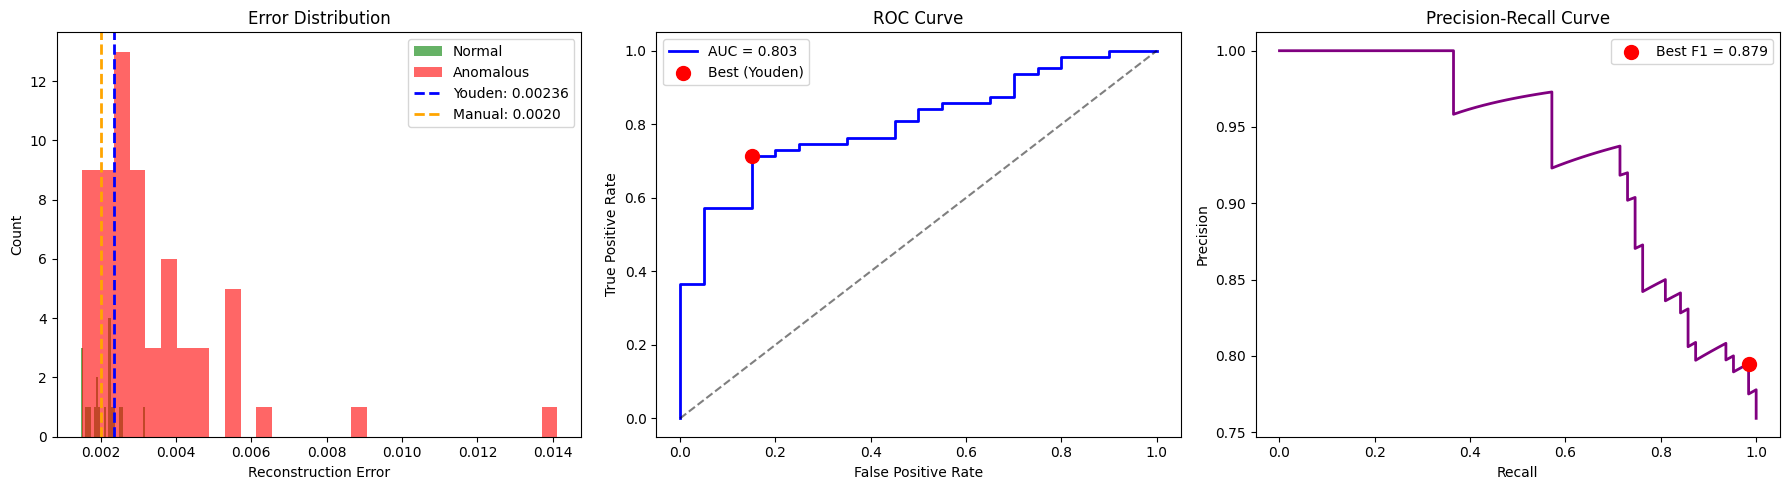

In [70]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


normal_errors = all_errors_np[all_labels_np == 0]
anomalous_errors = all_errors_np[all_labels_np == 1]

axes[0].hist(normal_errors, bins=30, alpha=0.6, label="Normal", color="green")
axes[0].hist(anomalous_errors, bins=30, alpha=0.6, label="Anomalous", color="red")
axes[0].axvline(threshold_youden, color="blue", linestyle="--", linewidth=2, label=f"Youden: {threshold_youden:.5f}")
axes[0].axvline(0.0020, color="orange", linestyle="--", linewidth=2, label=f"Manual: 0.0020")
axes[0].set_xlabel("Reconstruction Error")
axes[0].set_ylabel("Count")
axes[0].set_title("Error Distribution")
axes[0].legend()

# 2. ROC Curve
axes[1].plot(fpr, tpr, color="blue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].scatter(fpr[best_roc_idx], tpr[best_roc_idx], color="red", s=100, zorder=5, label=f"Best (Youden)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# 3. Precision-Recall Curve
axes[2].plot(recall, precision, color="purple", linewidth=2)
axes[2].scatter(recall[best_pr_idx], precision[best_pr_idx], color="red", s=100, zorder=5, label=f"Best F1 = {f1_scores[best_pr_idx]:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

In [71]:

best_threshold = threshold_youden 
print(f"Using optimal threshold: {best_threshold:.6f}")

optimal_preds = [1 if e > best_threshold else 0 for e in all_errors]

print(f"\nAccuracy: {accuracy_score(all_labels_np, optimal_preds):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(all_labels_np, optimal_preds))
print(f"\nClassification Report:")
print(classification_report(all_labels_np, optimal_preds, target_names=["Normal", "Anomaly"]))

Using optimal threshold: 0.002359

Accuracy: 0.7349

Confusion Matrix:
[[17  3]
 [19 44]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.47      0.85      0.61        20
     Anomaly       0.94      0.70      0.80        63

    accuracy                           0.73        83
   macro avg       0.70      0.77      0.70        83
weighted avg       0.82      0.73      0.75        83



In [72]:
torch.save(model.state_dict(), "linear_autoencoder.pth")